# AI/ML in Biology & Bioinformatics:
## Section 1: Biological Data Representation, Visualization & Feature Engineering

### 1. Representation & Dimensionality
Biological data is inherently high-dimensional and sparse:
*   **Transcriptomics (RNA-Seq):** Matrices where rows are samples and columns are thousands of gene expression levels ($p \gg n$).
*   **Genomics:** Sequential, categorical strings (A, C, G, T) requiring numeric encoding.

### 2. Feature Engineering Strategies
*   **K-mer Counting:** Breaking sequence data into overlapping substrings of length $k$ to construct frequency vectors.
*   **One-Hot Encoding:** Translating nucleotide or amino acid characters into binary vectors ($A = [1,0,0,0]$). This preserves position but loses context if sequences vary in length.
*   **Physicochemical Descriptors:** Mapping amino acids to physical properties (hydrophobicity, isoelectric point, molecular weight) instead of raw letters.

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

def generate_kmers(sequence, k=3):
    return [sequence[i:i+k] for i in range(len(sequence) - k + 1)]

sequence = "ATCGATCGATTG"
kmers = generate_kmers(sequence, k = 3)
print(f"Generated k-mers(k=3): {kmers}")

amino_acids = np.array(['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L']).reshape(-1, 1)
encoder = OneHotEncoder(sparse_output=False)
encoder.fit(amino_acids)

test_peptide = np.array(['A', 'G', 'C']).reshape(-1, 1)
one_hot_peptide = encoder.transform(test_peptide)
print(f"One-Hot Encoded Peptide (A, G, C): \n{one_hot_peptide}")

Generated k-mers(k=3): ['ATC', 'TCG', 'CGA', 'GAT', 'ATC', 'TCG', 'CGA', 'GAT', 'ATT', 'TTG']
One-Hot Encoded Peptide (A, G, C): 
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]


## Section 2: Dimensionality Reduction & Unsupervised Learning

### 1. PCA vs. t-SNE vs. UMAP in Single-Cell RNA-Seq (scRNA-Seq)
*   **PCA (Principal Component Analysis):** Linear reduction. Essential as a preprocessing step to remove noise, but fails to capture complex, non-linear cellular trajectories.
*   **UMAP:** Non-linear graph-based method. UMAP is heavily preferred in modern bioinformatics because it preserves both *local* (nearby cells stay nearby) and *global* topology (how distinct cell clusters relate to one another, relationships between clusters are more meaningful).
*   **t-SNE:** Non-linear graph-based method but only preserves *local* neighborhoods. Excellent at forming tight, clean clusters, but spacing between clusters is often meaningless. Two clusters may appear far apart in the plot even if biologically similar.

### 2. Clustering Biological Subtypes
*   **Hierarchical Clustering:** Used extensively for generating heatmaps of gene expression Profiles to identify co-expressed gene modules.
*   **K-Means:** Grouping samples into distinct disease subtypes based on biomarker expressions.

Explained variance ratio of top 2 PCs: 0.0394


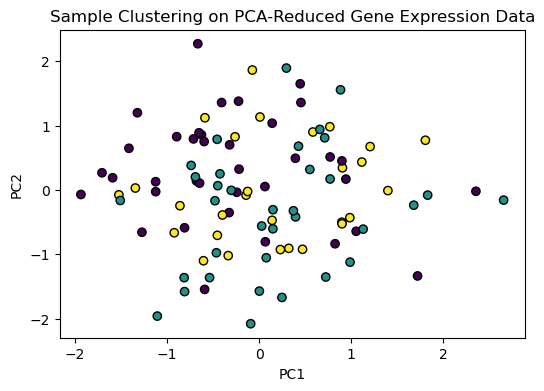

In [2]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

# Simulating high-dimensional RNA-Seq data (100 samples, 500 genes)
np.random.seed(42)
rna_seq_data = np.random.rand(100, 500)

# Apply PCA to reduce to top components
pca = PCA(n_components=10)
pca_features = pca.fit_transform(rna_seq_data)
print(f"Explained variance ratio of top 2 PCs: {pca.explained_variance_ratio_[:2].sum():.4f}")

# Hierarchical clustering to find 3 distinct sample sub-populations
cluster = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
cluster_labels = cluster.fit_predict(pca_features)

# Quick visual of the first two principal components color-coded by cluster
plt.figure(figsize=(6, 4))
plt.scatter(pca_features[:, 0], pca_features[:, 1], c=cluster_labels, cmap='viridis', edgecolors='k')
plt.title("Sample Clustering on PCA-Reduced Gene Expression Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Variance retained after PCA: 0.5487


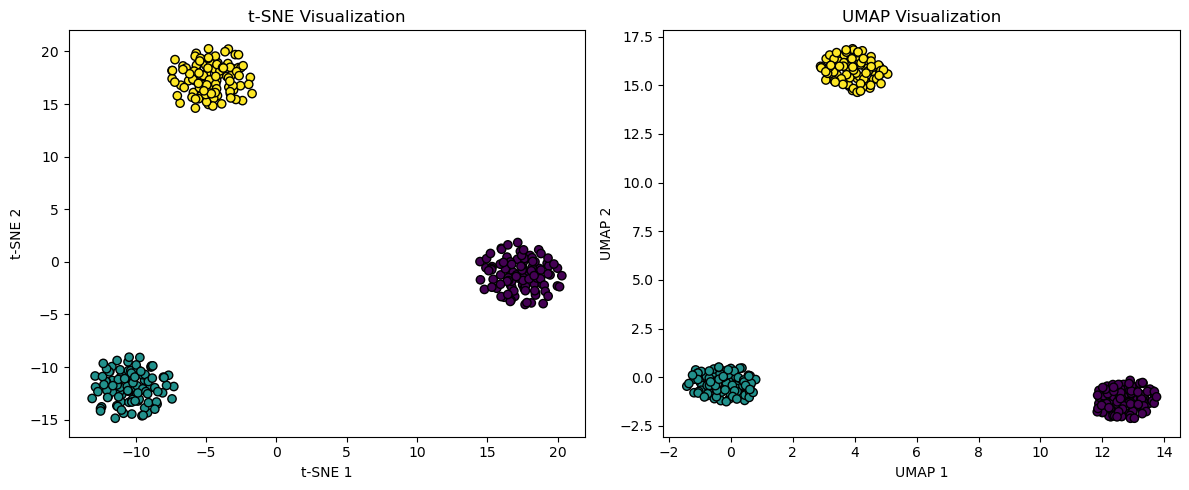

In [3]:
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap

import warnings
warnings.filterwarnings("ignore")

# ---------------------------------------------------
# Simulating high-dimensional scRNA-Seq-like data
# ---------------------------------------------------
# 300 cells, 500 genes, 3 biological populations

np.random.seed(42)

X, true_labels = make_blobs(
    n_samples=300,
    n_features=500,
    centers=3,
    cluster_std=8.0,
    random_state=42
)

# ---------------------------------------------------
# Step 1: PCA preprocessing (common in scRNA-Seq)
# ---------------------------------------------------
# Reduce noise before applying t-SNE/UMAP

pca = PCA(n_components=50)
X_pca = pca.fit_transform(X)

print(f"Variance retained after PCA: {sum(pca.explained_variance_ratio_):.4f}")

# ---------------------------------------------------
# Step 2: t-SNE dimensionality reduction
# ---------------------------------------------------

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_pca)

# ---------------------------------------------------
# Step 3: UMAP dimensionality reduction
# ---------------------------------------------------

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = umap_model.fit_transform(X_pca)

# ---------------------------------------------------
# Visualization
# ---------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# t-SNE Plot
axes[0].scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=true_labels,
    cmap='viridis',
    edgecolors='k'
)

axes[0].set_title("t-SNE Visualization")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")

# UMAP Plot
axes[1].scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=true_labels,
    cmap='viridis',
    edgecolors='k'
)

axes[1].set_title("UMAP Visualization")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")

plt.tight_layout()
plt.show()

The graphs here show very clearly separated data, t-SNE and UMAP can look almost identical. Since we used synthetic data using ***make_blobs(...)*** this creates:
* already well-separated clusters
* clean boundaries
* no overlap
* no trajectories

So both algorithms easily identify the 3 populations.

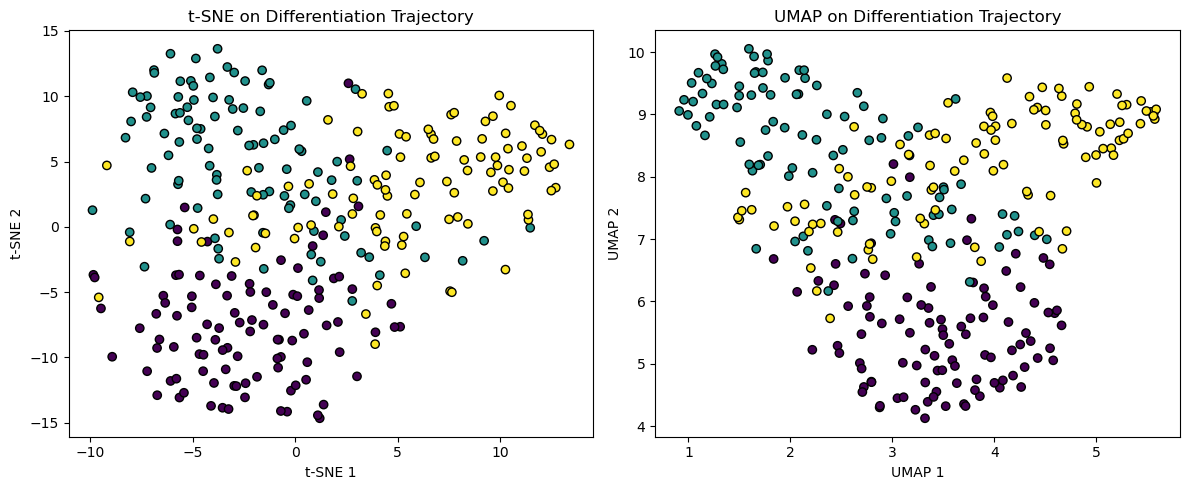

In [4]:
# ---------------------------------------------------
# Simulating a branching cell differentiation trajectory
# ---------------------------------------------------

np.random.seed(42)

n_cells = 300
n_genes = 100

# Root stem-cell trajectory
t = np.linspace(0, 1, n_cells // 3)

branch1 = np.array([
    t,
    t**2
]).T

branch2 = np.array([
    t,
    -t**2
]).T

root = np.array([
    -t,
    np.zeros_like(t)
]).T

trajectory = np.vstack([root, branch1, branch2])

# Add high-dimensional noisy gene features
noise = np.random.normal(0, 0.2, (trajectory.shape[0], n_genes - 2))

high_dim_data = np.hstack([trajectory, noise])

# Labels for visualization
labels = np.array(
    [0]*(n_cells//3) +
    [1]*(n_cells//3) +
    [2]*(n_cells//3)
)

# ---------------------------------------------------
# PCA preprocessing
# ---------------------------------------------------

pca = PCA(n_components=20)
X_pca = pca.fit_transform(high_dim_data)

# ---------------------------------------------------
# t-SNE
# ---------------------------------------------------

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_pca)

# ---------------------------------------------------
# UMAP
# ---------------------------------------------------

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=20,
    min_dist=0.1,
    random_state=42
)

X_umap = umap_model.fit_transform(X_pca)

# ---------------------------------------------------
# Visualization
# ---------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# t-SNE Plot
axes[0].scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=labels,
    cmap='viridis',
    edgecolors='k'
)

axes[0].set_title("t-SNE on Differentiation Trajectory")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")

# UMAP Plot
axes[1].scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=labels,
    cmap='viridis',
    edgecolors='k'
)

axes[1].set_title("UMAP on Differentiation Trajectory")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")

plt.tight_layout()
plt.show()

| Property                | t-SNE     | UMAP         |
| ----------------------- | --------- | ------------ |
| Local clustering        | Strong    | Strong       |
| Global topology         | Weak      | Better       |
| Branch preservation     | Poor      | Better       |
| Biological trajectories | Distorted | Preserved    |
| Continuum structure     | Broken    | More visible |


Here we used synthetic data again but we created 3 groups of cells. This mimics how real stem cells gradually differenciate into a specific cell type or a specialized cell.

        
Stem Cells ---> Cell Type A <br>
     | <br>
     v <br>
Cell Type B
            
#### How the Data Was Constructed
##### 1. Root Population (Stem Cells)
root = np.array([
    -t,
    np.zeros_like(t)
]).T

This creates cells along a straight path.

Biological meaning:

undifferentiated stem/progenitor cells
starting point of development

These are the ***teal***-colored cells in your graph.

##### 2. Upper Branch
branch1 = np.array([
    t,
    t**2
]).T

This creates a curved upward trajectory.

Biological meaning:

one differentiation pathway
cells becoming a specialized subtype

These are the ***yellow*** cells.

##### 3. Lower Branch
branch2 = np.array([
    t,
    -t**2
]).T

This creates a curved downward trajectory.

Biological meaning:

second differentiation lineage
another mature cell type

These are the ***purple*** cells.


##### Note:
On real scRNA-seq datasets:

UMAP differences become dramatically clearer
especially with:
* pseudotime analysis
* lineage inference
* developmental biology datasets

That’s why nearly every modern single-cell paper now uses UMAP as the default visualization.

## Section 3: Deep Learning Architectures for Sequence & Structural Biology

### 1. Convolutional Neural Networks (CNNs) in Genomics
*   **Input Shape:** 2D tensors representing one-hot encoded genomic sequences (Length $\times$ 4 channels).
*   **Mechanism:** 1D Convolutions act as **position-weight matrix (PWM) scanners**, moving along the sequence to detect localized functional motifs (e.g., transcription factor binding sites, splice junctions).

### 2. Recurrent Neural Networks (RNNs) for Sequences
*   RNNs are the original neural networks designed for sequential data.They process input step-by-step. While maintaining a hidden memory state.  [x1 → x2 → x3 → x4]

*   Processes sequence elements recursively using a hidden state: <br> h_t = f(Wx_t + Uh_{t-1})

  where:

x_t = current input <br>
h{t−1} = previous hidden state

*   Standard RNNs struggle with long-range dependencies because of vanishing gradients and exploding gradients. For example A motif appearing 500 bases earlier may still matter later in the sequence. Vanilla RNNs often forget such distant information.

*   Used for processing variable-length protein sequences or longitudinal patient EHR data.
*   *Note:* Largely superseded by Transformers (Self-Attention) in modern structural biology, but still baseline architectures for sequential feature extraction.

#### Long Short-Term Memoory Networks (LSTMs)
*   LSTM is a specialized RNN variant designed to retain long-term sequence information.
*   Mechanism: input gate, forget gate, output gate, memory cell.<br> To selectively store important information.
*   Unlike standard RNN it is excellent for long-range dependency learning and handles complex biological sequences effectively.
*   However it is computationally expensive and other limitations like larger parameter count and slower training.
*   Example use case: Protein folding and long genomic dependency analysis.

#### Gated Recurrent Units (GRUs)
*   It is a simplified version of LSTM.
*   Mechanism: update gate, reset gate, withoout a separate memory cell
*   Its strengths are faster training and fewer parameters
*   It performs well on moderate-length sequences
*   In some cases it is slightly less expressive than LSTM
*   Example use case: Clinical time-series prediction and medium-length sequence modeling.

| Feature                     | Vanilla RNN     | LSTM                   | GRU                           |
| --------------------------- | --------------- | ---------------------- | ----------------------------- |
| Long-term memory            | Weak            | Excellent              | Very Good                     |
| Training speed              | Fast            | Slowest                | Faster                        |
| Complexity                  | Low             | High                   | Medium                        |
| Parameters                  | Few             | Many                   | Moderate                      |
| Vanishing-gradient handling | Poor            | Excellent              | Excellent                     |
| Best for                    | Short sequences | Very long dependencies | Efficient sequential learning |


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

warnings.filterwarnings("ignore")

# =========================================================
# Simulating One-Hot Encoded DNA Sequences
# =========================================================
# Batch Size = 8
# Sequence Length = 100
# Channels = 4 (A, C, G, T)

sequence_batch = np.random.randn(8, 100, 4).astype(np.float32)

print("Input Shape:", sequence_batch.shape)

# =========================================================
# 1. CNN for Genomic Motif Detection
# =========================================================
# Conv1D acts like a motif scanner (PWM scanner)

cnn_model = models.Sequential([
    
    # Detect local motifs in DNA sequence
    layers.Conv1D(
        filters=16,
        kernel_size=9,
        padding='same',
        activation='relu',
        input_shape=(100, 4)
    ),
    
    # Downsample important activations
    layers.MaxPooling1D(pool_size=2),
    
    # Convert feature maps into vector
    layers.Flatten(),
    
    # Binary classification
    layers.Dense(2, activation='softmax')
])

cnn_output = cnn_model(sequence_batch)

print("\nCNN Output Shape:", cnn_output.shape)

# =========================================================
# 2. Vanilla RNN for Sequential Processing
# =========================================================
# Processes sequence step-by-step

rnn_model = models.Sequential([
    
    layers.SimpleRNN(
        units=32,
        input_shape=(100, 4)
    ),
    
    layers.Dense(2, activation='softmax')
])

rnn_output = rnn_model(sequence_batch)

print("Vanilla RNN Output Shape:", rnn_output.shape)

# =========================================================
# 3. LSTM for Long-Term Dependencies
# =========================================================
# Better memory handling using gates

lstm_model = models.Sequential([
    
    layers.LSTM(
        units=32,
        input_shape=(100, 4)
    ),
    
    layers.Dense(2, activation='softmax')
])

lstm_output = lstm_model(sequence_batch)

print("LSTM Output Shape:", lstm_output.shape)

# =========================================================
# 4. GRU for Efficient Sequential Learning
# =========================================================
# Faster alternative to LSTM

gru_model = models.Sequential([
    
    layers.GRU(
        units=32,
        input_shape=(100, 4)
    ),
    
    layers.Dense(2, activation='softmax')
])

gru_output = gru_model(sequence_batch)

print("GRU Output Shape:", gru_output.shape)

Input Shape: (8, 100, 4)

CNN Output Shape: (8, 2)
Vanilla RNN Output Shape: (8, 2)
LSTM Output Shape: (8, 2)
GRU Output Shape: (8, 2)


In [7]:
# =========================================================
# EXTENSION:
# Compare Model Complexity + Predictions
# =========================================================

print("\n" + "="*60)
print("MODEL SUMMARIES")
print("="*60)

# ---------------------------------------------------------
# CNN Summary
# ---------------------------------------------------------

print("\nCNN MODEL SUMMARY\n")
cnn_model.summary()

# ---------------------------------------------------------
# RNN Summary
# ---------------------------------------------------------

print("\nVANILLA RNN MODEL SUMMARY\n")
rnn_model.summary()

# ---------------------------------------------------------
# LSTM Summary
# ---------------------------------------------------------

print("\nLSTM MODEL SUMMARY\n")
lstm_model.summary()

# ---------------------------------------------------------
# GRU Summary
# ---------------------------------------------------------

print("\nGRU MODEL SUMMARY\n")
gru_model.summary()

# =========================================================
# Compare Number of Trainable Parameters
# =========================================================

print("\n" + "="*60)
print("TRAINABLE PARAMETER COMPARISON")
print("="*60)

print(f"CNN Parameters  : {cnn_model.count_params()}")
print(f"RNN Parameters  : {rnn_model.count_params()}")
print(f"LSTM Parameters : {lstm_model.count_params()}")
print(f"GRU Parameters  : {gru_model.count_params()}")

# =========================================================
# Compare Predictions
# =========================================================

print("\n" + "="*60)
print("MODEL PREDICTIONS")
print("="*60)

print("\nCNN Predictions:")
print(cnn_output.numpy()[:3])

print("\nRNN Predictions:")
print(rnn_output.numpy()[:3])

print("\nLSTM Predictions:")
print(lstm_output.numpy()[:3])

print("\nGRU Predictions:")
print(gru_output.numpy()[:3])




MODEL SUMMARIES

CNN MODEL SUMMARY



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 100, 16)        │           592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         1,602 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,194 (8.57 KB)

 Trainable params: 2,194 (8.57 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         3,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,714 (14.51 KB)

 Trainable params: 3,714 (14.51 KB)

 Non-trainable params: 0 (0.00 B)


TRAINABLE PARAMETER COMPARISON
CNN Parameters  : 2194
RNN Parameters  : 1250
LSTM Parameters : 4802
GRU Parameters  : 3714

MODEL PREDICTIONS

CNN Predictions:
[[0.5136379  0.48636213]
 [0.61284155 0.38715845]
 [0.323869   0.676131  ]]

RNN Predictions:
[[0.3419652  0.6580348 ]
 [0.33271027 0.6672898 ]
 [0.49629882 0.50370115]]

LSTM Predictions:
[[0.52205884 0.47794116]
 [0.49060813 0.50939184]
 [0.47997454 0.52002543]]

GRU Predictions:
[[0.5334189  0.46658114]
 [0.44244018 0.55755985]
 [0.480644   0.519356  ]]


## Biological Interpretation

CNN:
- Learns local sequence motifs
- Best for motif scanning and promoter detection
- Convolution filters behave like PWM scanners

Vanilla RNN:
- Learns sequential order
- Struggles with long-range dependencies

LSTM:
- Uses memory cells + gates
- Better for long genomic/protein dependencies

GRU:
- Similar to LSTM but computationally simpler
- Faster training with fewer parameters


### Parameter Comparison Insight
| Model | Parameters | Interpretation              |
| ----- | ---------- | --------------------------- |
| RNN   | 1250       | Simplest sequential learner |
| CNN   | 2194       | Learns local motifs         |
| GRU   | 3714       | Efficient memory learning   |
| LSTM  | 4802       | Strongest long-term memory  |


## Conclusion
| Model       | Best Use Case                        |
| ----------- | ------------------------------------ |
| CNN         | Local motif detection                |
| Vanilla RNN | Simple sequence modeling             |
| LSTM        | Complex long biological dependencies |
| GRU         | Faster efficient sequential learning |


## Section 4: Data Quality & Preprocessing

### 1. Handling Missing Data (Imputation)
*   **Biological Context:** Mass spectrometry (Proteomics) and scRNA-Seq suffer from massive "dropout" events (true expressions read as zero or missing due to technical detection limits).
*   **Strategy:** KNN Imputation or Matrix Factorization is used over mean/median replacement to preserve complex biological correlations across features.

### 2. Normalization & Transformation
*   **RNA-Seq:** Raw read counts must be scaled by library depth and gene length (**TPM** - Transcripts Per Million, or **RPKM**).
*   **Log Transformation:** $log1p(x) = \log(x + 1)$ is applied to stabilize variance across highly skewed expression profiles.